# E-commerce Product Analytics: EDA

This notebook explores synthetic e-commerce data generated for a product analytics pet project.

Main goals:

- inspect the dataset structure
- calculate core business metrics
- analyze revenue dynamics
- analyze the product funnel
- compare product categories and device types

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data" / "sample"
FIGURES_DIR = BASE_DIR / "dashboards" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data

The project uses six main tables:

- users
- products
- sessions
- orders
- order_items
- events

In [2]:
users = pd.read_csv(DATA_DIR / "users.csv", parse_dates=["signup_date", "first_session_at"])
products = pd.read_csv(DATA_DIR / "products.csv", parse_dates=["created_at"])
sessions = pd.read_csv(
    DATA_DIR / "sessions.csv",
    parse_dates=["session_started_at", "session_ended_at"],
)
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_created_at"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
events = pd.read_csv(DATA_DIR / "events.csv", parse_dates=["event_time"])

tables = {
    "users": users,
    "products": products,
    "sessions": sessions,
    "orders": orders,
    "order_items": order_items,
    "events": events,
}

pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": df.shape[1]} for name, df in tables.items()]
)

,table,rows,columns
0,users,500,9
1,products,16,8
2,sessions,2225,8
3,orders,425,8
4,order_items,425,6
5,events,6752,7


## 2. Overall Metrics

We calculate core project KPIs:

- users
- sessions
- paid orders
- revenue
- average order value
- session-to-order conversion

In [3]:
paid_orders = orders[orders["payment_status"] == "paid"].copy()

overall_metrics = pd.DataFrame(
    [
        {
            "users_count": users["user_id"].nunique(),
            "sessions_count": sessions["session_id"].nunique(),
            "paid_orders_count": paid_orders["order_id"].nunique(),
            "revenue": paid_orders["total_amount"].sum(),
            "average_order_value": paid_orders["total_amount"].mean(),
            "session_to_order_conversion": (
                paid_orders["order_id"].nunique() / sessions["session_id"].nunique()
            ),
        }
    ]
)

overall_metrics

,users_count,sessions_count,paid_orders_count,revenue,average_order_value,session_to_order_conversion
0,500,2225,425,221082.4,520.193882,0.191011


**Interpretation**

This table gives a high-level view of the product.
These KPIs are usually used as dashboard cards in BI tools.

## 3. Monthly Revenue Dynamics

In [4]:
paid_orders["month"] = paid_orders["order_created_at"].dt.to_period("M").dt.to_timestamp()

monthly_metrics = (
    paid_orders.groupby("month", as_index=False)
    .agg(
        revenue=("total_amount", "sum"),
        paid_orders_count=("order_id", "nunique"),
        average_order_value=("total_amount", "mean"),
    )
    .sort_values("month")
)

monthly_metrics.tail()

,month,revenue,paid_orders_count,average_order_value
10,2025-11-01,15598.80,33,472.690909
11,2025-12-01,23873.00,48,497.354167
12,2026-01-01,17046.21,28,608.793214
13,2026-02-01,8221.24,17,483.602353
14,2026-03-01,1977.44,5,395.488000


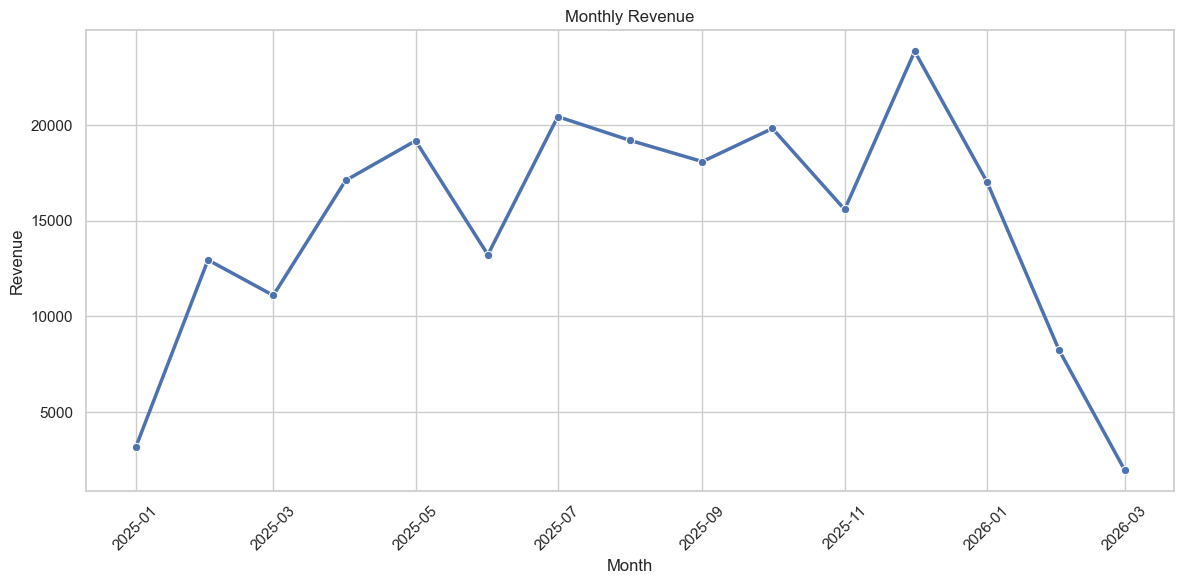

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_metrics, x="month", y="revenue", marker="o", linewidth=2.5)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue.png", dpi=160)
plt.show()

**Interpretation**

Monthly revenue helps detect seasonality, growth periods, and possible drops.
In the current generated dataset, December 2025 is the strongest month by revenue and order count.

## 4. Funnel Analysis

Funnel steps:

1. `view_item`
2. `add_to_cart`
3. `purchase`

In [6]:
funnel_order = ["view_item", "add_to_cart", "purchase"]
funnel = (
    events.groupby("event_type", as_index=False)
    .agg(users_count=("user_id", "nunique"))
    .set_index("event_type")
    .loc[funnel_order]
    .reset_index()
)

funnel["conversion_from_previous_step"] = (
    funnel["users_count"] / funnel["users_count"].shift(1)
)
funnel["conversion_from_first_step"] = funnel["users_count"] / funnel.loc[0, "users_count"]

funnel

,event_type,users_count,conversion_from_previous_step,conversion_from_first_step
0,view_item,500,NaN,1.00
1,add_to_cart,385,0.770000,0.77
2,purchase,290,0.753247,0.58


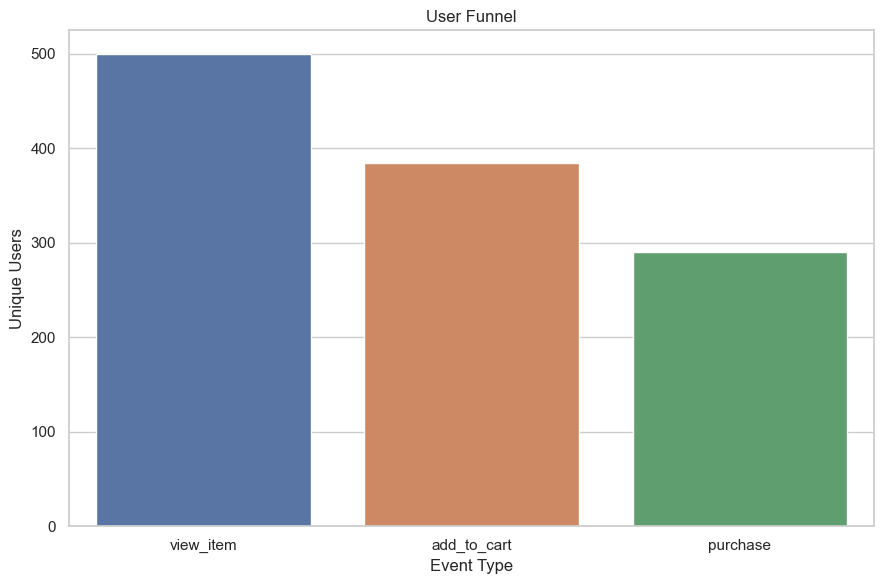

In [7]:
plt.figure(figsize=(9, 6))
sns.barplot(data=funnel, x="event_type", y="users_count", hue="event_type", legend=False)
plt.title("User Funnel")
plt.xlabel("Event Type")
plt.ylabel("Unique Users")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "user_funnel.png", dpi=160)
plt.show()

**Interpretation**

The funnel shows where users drop off before purchase.
This is one of the core tools in product analytics.

## 5. Revenue by Product Category

In [8]:
category_revenue = (
    order_items.merge(paid_orders[["order_id"]], on="order_id", how="inner")
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(revenue=("item_amount", "sum"), items_sold=("quantity", "sum"))
    .sort_values("revenue", ascending=False)
)

category_revenue

,category,revenue,items_sold
1,Electronics,80141.63,212
2,Home,67450.40,222
3,Sports,48133.28,183
0,Beauty,32551.16,211


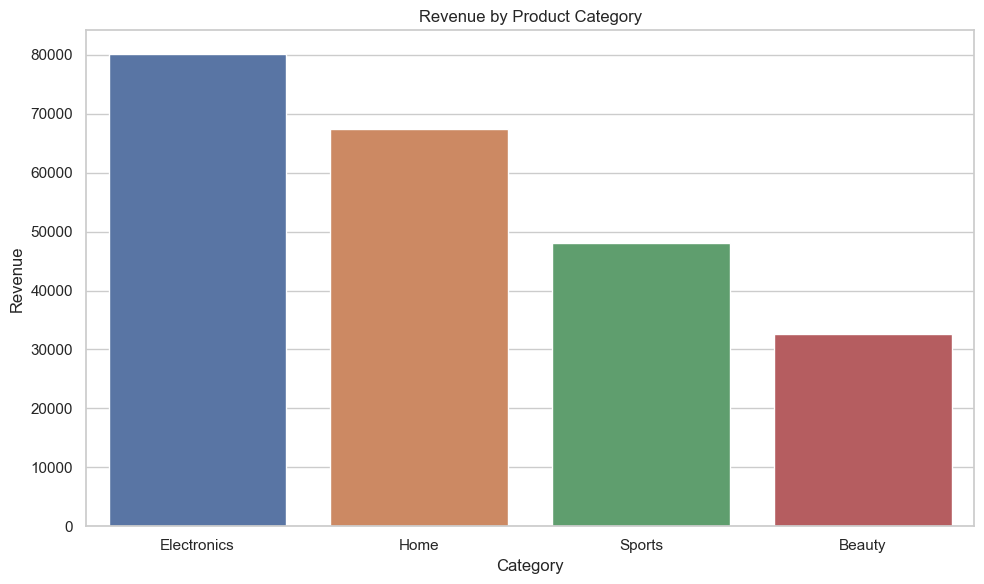

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue, x="category", y="revenue", hue="category", legend=False)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "category_revenue.png", dpi=160)
plt.show()

**Interpretation**

Category analysis helps identify the main revenue drivers.
In the current dataset, Electronics and Home are the strongest categories by revenue.

## 6. Device Conversion

In [10]:
paid_orders["order_date"] = paid_orders["order_created_at"].dt.date
sessions["session_date"] = sessions["session_started_at"].dt.date

device_metrics = (
    sessions.merge(
        paid_orders[["order_id", "user_id", "order_date", "total_amount"]],
        left_on=["user_id", "session_date"],
        right_on=["user_id", "order_date"],
        how="left",
    )
    .groupby("device_type", as_index=False)
    .agg(
        sessions_count=("session_id", "nunique"),
        paid_orders_count=("order_id", "nunique"),
        revenue=("total_amount", "sum"),
    )
)

device_metrics["session_to_order_conversion"] = (
    device_metrics["paid_orders_count"] / device_metrics["sessions_count"]
)

device_metrics.sort_values("session_to_order_conversion", ascending=False)

,device_type,sessions_count,paid_orders_count,revenue,session_to_order_conversion
0,desktop,843,178,97783.89,0.211151
2,tablet,712,141,76518.75,0.198034
1,mobile,670,102,52350.45,0.152239


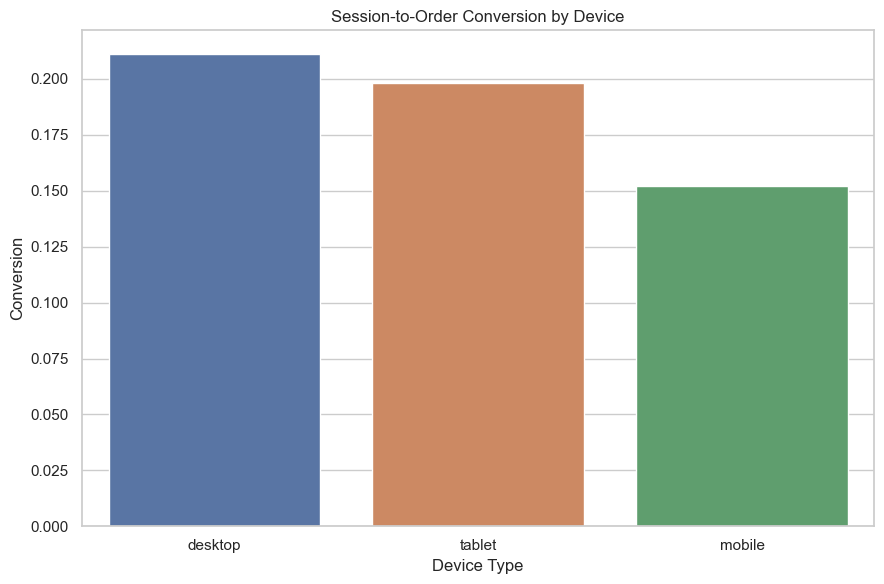

In [11]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=device_metrics.sort_values("session_to_order_conversion", ascending=False),
    x="device_type",
    y="session_to_order_conversion",
    hue="device_type",
    legend=False,
)
plt.title("Session-to-Order Conversion by Device")
plt.xlabel("Device Type")
plt.ylabel("Conversion")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "device_conversion.png", dpi=160)
plt.show()

**Interpretation**

Device analysis helps find UX or checkout problems.
In this dataset, desktop users convert better than mobile users.

## 7. Final Notes

This notebook covers the first EDA stage.

Next possible steps:

- connect notebook directly to PostgreSQL
- add acquisition cost data
- calculate CAC, LTV, and payback
- build Power BI dashboard
- add a simple ML model for purchase probability